In [1]:
''' 
read data from a pedestal run, and create a file of mean pedestal values by channel
(to be used in other analyses)
'''

import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from pathlib import Path
from datetime import datetime
from scipy.stats import truncnorm

##########################################################
# Initialize parameters  
##########################################################

# cold tests of set 2 of 10 tiles
#filename = "/data/v3/10x16/set2_10_tile_tests_20260312/data/cold/packet-cold_ped_set2_10tiles_480s_220vref_4.hdf5"

# cold tests of set 3 of 10 tiles
filename = "/data/v3/10x16/set3_10_tile_tests_20260505/data/cold/packet-cold_ped_set3_9tiles_240s_220vref_no_hotchan_4.hdf5"

# cold test of set 4, 10 tiles
#filename = "/data/v3/10x16/set4_10_tile_tests_20260512/data/cold/packet-cold_ped_set4_10tiles_240s_no_hotchan_links_disabled.hdf5"

# tiles tested in this filename or the subset of tiles on which you wish to use 
#tiles = [1,2,3,4,5,6,7,8,9,10]
tiles = [2,3,4]
#tiles = [2]

# serial numbers for sets 2, 3 and 4 
if "set2" in filename:
    chip_serial_number_list = ['', '4k04582', '4k04905', '4k03080', '4k04087', '4k04249', '4k00104', '4k01300', '4K04411', '4K01733', '4K00770' ]
elif "set3" in filename:
    chip_serial_number_list = ['', '4k00952', '4k03591', '4k03936', '4k00607', '4k00450', '4k04834', '4k00101', '4K00277', '4K03329', '4K03496' ]
elif "set4" in filename:
    chip_serial_number_list = ['', '4k01892', '4k02056', '4k02219', '4k02371', '4k00450', '4k04834', '4k00101', '4K00277', '4K03329', '4K03496' ]    

# establish the # of stdev to use when truncating the pedestal distribution
n_stdev = 2.5

debug = False

# initialize
ig = 1 
first_tile = True
pedestals = [[0 for chn in range(64)] for chp in range(171)]
stdevs    = [[0 for chn in range(64)] for chp in range(171)]

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
def get_io_channels(tile):

    # each tile has up to 4 io_channels that uniquely identify the tile within an io_group
    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
        ]
    
    return io_ch_per_tile[tile]


In [3]:
def truncate_distribution(mean, std_dev):
    """
    Calculate the standard deviation of a truncated normal distribution.

    Parameters:
        mean (float): Mean of the original normal distribution.
        std_dev (float): Standard deviation of the original normal distribution.
        lower (float): Lower bound of truncation.
        upper (float): Upper bound of truncation.

    Returns:
        float: Standard deviation of the truncated distribution.
    """

    global n_stdev
    
    lower = max(0, mean - n_stdev * std_dev)
    upper = mean + n_stdev * std_dev
    
    # Convert bounds to standard normal space
    a, b = (lower - mean) / std_dev, (upper - mean) / std_dev

    # Create truncated normal distribution and get the new mean
    dist = truncnorm(a, b, loc=mean, scale=std_dev)
    
    return dist.std(), dist.mean()

In [4]:
def get_pedestals(filename, tile, chip_serial_number, ig):
    
    global pedestals, debug
    
    # initialize
    first_chan = True
    verbose = False
    pkt_count = [[[0 for wrd in range(1000)] for chn in range(64)] for chp in range(256)]
    pedestal_list = []

    # read packet data from initialized file name
    f = h5py.File(filename, 'r')
    packets = f['packets'][:]
    
    # create arrays of data packets
    data_mask     = f['packets'][:]['packet_type']  == 1
    data_pkts     = packets[data_mask]

    # identify io_channels with data packets in this data file
    unique_io_channels = list(dict.fromkeys(data_pkts['io_channel'][:]))
    unique_io_channels = sorted(unique_io_channels)

    # print out run statistics for the file
    unixtime = f['packets'][:]['timestamp'][f['packets'][:]['packet_type'] == 4]
    livetime = np.max(unixtime)-np.min(unixtime)        
    npkts         = len(data_pkts)         
    
    # get a list of the io_channels that could be enabled for a given tile, and then determine which
    # ones were enabled
    io_channel_ids = get_io_channels(tile)
    enabled_io_channels = list(set(io_channel_ids) & set(unique_io_channels))
    
    # mask for the chosen tile
    tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
    data_pkts = data_pkts[tile_mask]
    npkts     = len(data_pkts)   

    # check for tiles with no data    
    if npkts ==0: 
        print(f'There are no data packets for tile {tile}')        
        return  
    else:      
        print(f"\nTile {tile}: {npkts:,} data packets with avg rate {npkts/livetime:,.0f} pkts/s over {livetime}s of data taking\n")  
       
    # mask for chip
    for chip in range(11, 171):
        
        chip_mask = data_pkts['chip_id'] == chip
        chip_pkts = data_pkts[chip_mask]  
        
        # mask for channel
        for chan in range(64):

            chan_mask = chip_pkts['channel_id'] == chan
            chan_pkts = chip_pkts[chan_mask]
            chan_adc  = chan_pkts['dataword']

            # remove zero datawords
            non_zero_chan_adc = chan_adc[chan_adc != 0]
            npkts_chan = len(non_zero_chan_adc)

            # calculate the pedestal for this channel as the mean non-zero dataword
            if npkts_chan > 2:

                mean_ped  = np.mean(non_zero_chan_adc)
                
                # deal with channels that have extreme pedestal means
                if mean_ped > 300:
                        
                    # remove extreme jumps
                    non_zero_chan_adc = [x for x in non_zero_chan_adc if x<100]
                    extreme_pkts      = [x for x in non_zero_chan_adc if x>=100]

                    # some channels only have extreme pedestal values
                    if len(non_zero_chan_adc) < 2:
                        mean_ped = np.mean(extreme_pkts)
                        
                    # it is unclear why, but there are rare cases where np.mean() results in an artificially large 
                    # number, but a simple algebraic average is correct                    
                    else:
                        sum_of_ped = sum(x for x in non_zero_chan_adc)
                        n = sum(1 for x in non_zero_chan_adc)          
                        mean_ped = sum_of_ped / n
                
                std = np.std(non_zero_chan_adc)
                
                # truncate the distribution at the chosen n_stdev to remove tails before calculating mean and std
                if std > 0:
                    old_mean = mean_ped
                    old_std  = std
                    std, mean_ped = truncate_distribution(mean_ped, std)
                    
                # sometimes the function truncate_distribution returns NAN
                if np.isnan(mean_ped):
                    if np.isnan(old_mean):
                        mean_ped = 288
                    else:
                        mean_ped = old_mean

                if np.isnan(std):
                    if np.isnan(old_std):
                        std = 0
                    else:
                        std = old_std
                
                pedestals[chip][chan] = int(mean_ped)
                stdevs[chip][chan] = std
                
                pedestal_list.append(mean_ped)
            
            else:
                pedestals[chip][chan] = 288

    mean_ped_tile = np.mean(pedestal_list)

    write_ped_to_file(filename, tile, chip_serial_number_list[tile], pedestals, stdevs)
    
    # graph the pedestals for this tile
    fig, axis = plt.subplots(1,2, figsize=(10, 5))
    plt.suptitle(f'Tile {tile}: Pedestals per Channel (left: all, right: zoom)\nMean Pedestal = {mean_ped_tile:.0f} for Benchtop test of v3a Tile #{tile} ({chip_serial_number})')
    
    axis[0].hist(pedestal_list, bins = 200)
    #axis[0].set_title(f'Mean Datawords per Channel on Tile {tile}\nBenchtop test of v3a Tile #{tile} ({chip_serial_number})')
    axis[0].set_xlabel(f'Mean Dataword')
    axis[0].set_ylabel(f'Channel Count')

    axis[1].hist(pedestal_list, bins = 200)
    #axis[1].set_title(f'Mean Datawords per Channel on Tile {tile}\nBenchtop test of v3a Tile #{tile} ({chip_serial_number})')
    axis[1].set_xlim(288-50, 288+50)
    axis[1].set_xlabel(f'Mean Dataword')
    axis[1].set_ylabel(f'Channel Count')
    
    plt.show
    
    return

In [5]:
'''
create a file of pedestals per tile
'''

def write_ped_to_file(file, tile, chip_serial_number, pedestals, stdevs):   

    # determine if this was a warm or cold data run (info for filename)
    if "warm" in file:
        temp = "warm"
    elif "cold" in file:
        temp = "cold"
    else:
        print(f"Problem: the file name does not indicate warm or cold")
    
    filename = f'../data/pedestals_{temp}_tile{tile}_{chip_serial_number}.hdf5'
    
    with h5py.File(filename, 'w') as f:
            
        f.create_dataset('pedestals', data = pedestals, dtype=int)
        f.create_dataset('stdevs', data = stdevs, dtype=float)
        
        f.close()  

    print(f"\nPedestal file written to {filename}\n")
    
    return


Run Statistics for Data File /data/v3/10x16/set3_10_tile_tests_20260505/data/cold/packet-cold_ped_set3_9tiles_240s_220vref_no_hotchan_4.hdf5:

Tile 2: 2,566,738 data packets with avg rate 10,650 pkts/s over 241s of data taking



/home/cmcnulty/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/cmcnulty/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/cmcnulty/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/cmcnulty/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/cmcnulty/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Pedestal file written to ../data/pedestals_cold_tile2_4k03591.hdf5


Tile 3: 2,566,738 data packets with avg rate 10,650 pkts/s over 241s of data taking


Pedestal file written to ../data/pedestals_cold_tile3_4k03936.hdf5


Tile 4: 2,566,736 data packets with avg rate 10,650 pkts/s over 241s of data taking


Pedestal file written to ../data/pedestals_cold_tile4_4k00607.hdf5



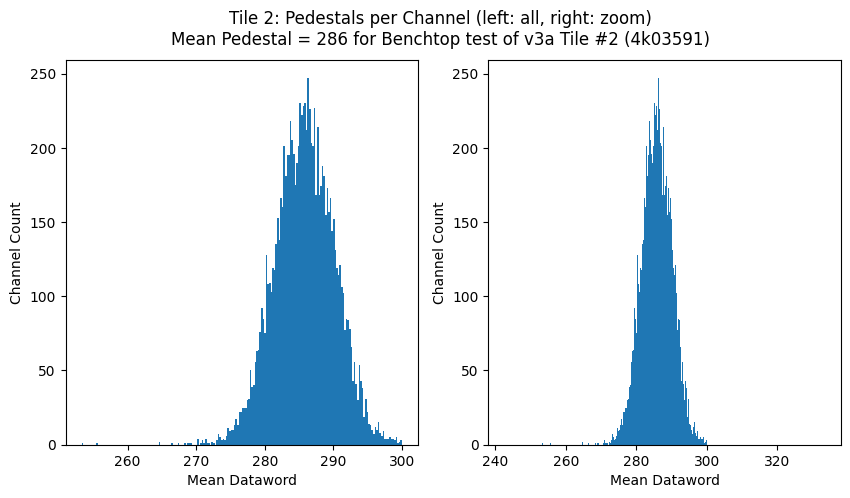

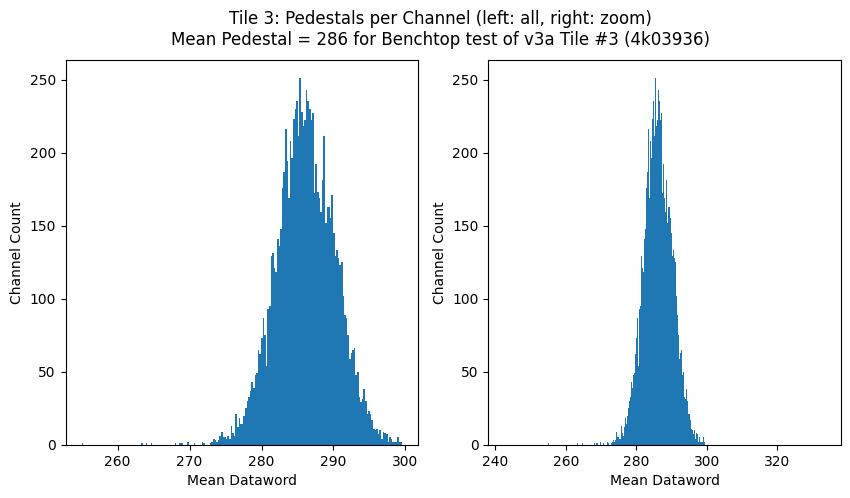

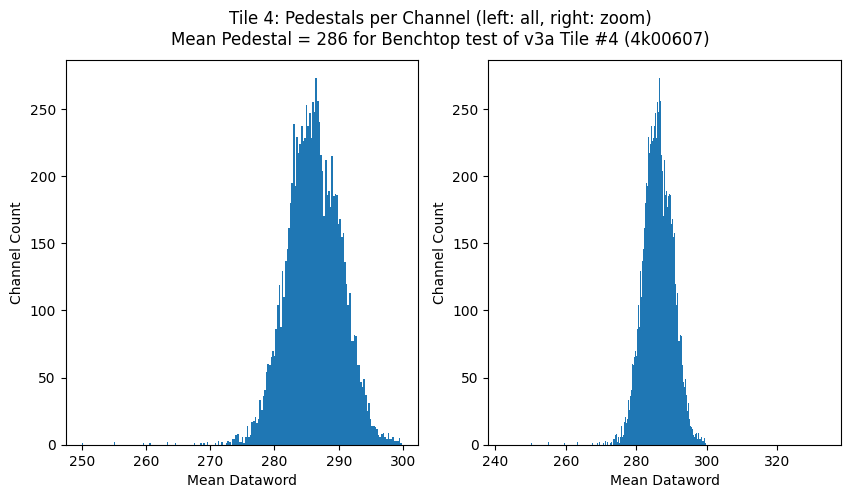

In [6]:
####################
# main
####################

print(f'Run Statistics for Data File {filename}:')

for tile in tiles:
    
    get_pedestals(filename, tile, chip_serial_number_list[tile], ig)
    